Train:    (66507, 30)
Val:      (22170, 30)
Test:     (22170, 30)
TrainVal: (88677, 30)
Iniciando optimización Optuna — 75 trials...
Métrica: 70% Recall At Risk + 30% F1-macro



  0%|          | 0/75 [00:00<?, ?it/s]


✅ Optimización completada
   Mejor valor:  0.5431
   Mejor trial:  #25
MEJORES HIPERPARÁMETROS:
  n_estimators           655
  max_depth              9
  learning_rate          0.14339608437672377
  min_child_weight       8
  subsample              0.8544897306731536
  colsample_bytree       0.7387292708660363
  gamma                  4.536078873768213

Comparativa base vs optimizado:
  Parámetro                    Base     Optuna
  --------------------------------------------
  n_estimators                  200        655 ←
  max_depth                       6          9 ←
  learning_rate                 0.1     0.1434 ←
  min_child_weight                1          8 ←
  subsample                     1.0     0.8545 ←
  colsample_bytree              1.0     0.7387 ←
  gamma                           0     4.5361 ←


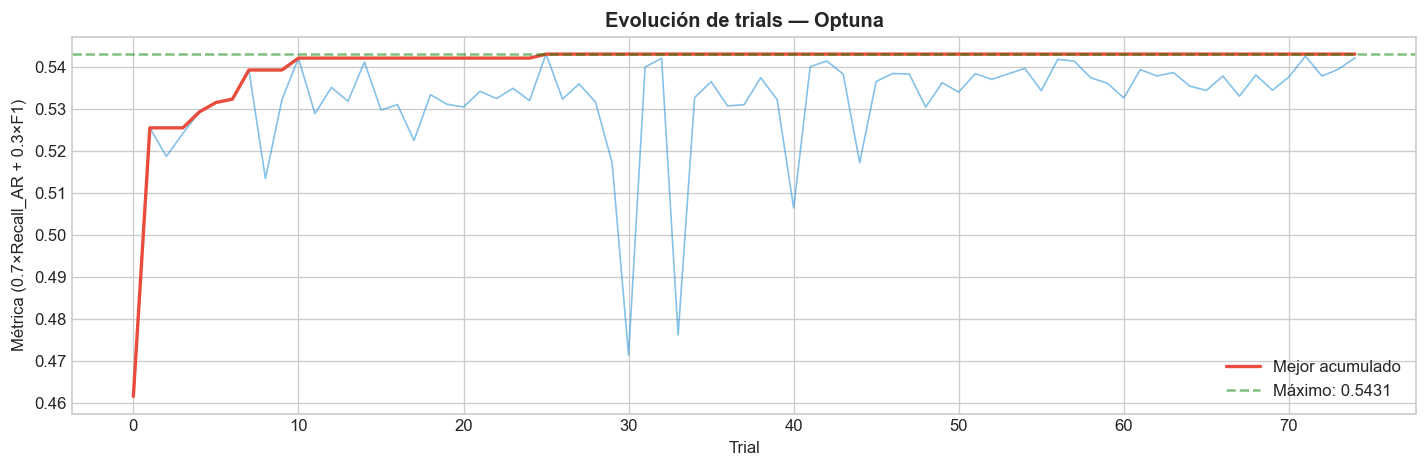

MODELO OPTIMIZADO — resultados en validación:
  ⚠️   F1-macro:     0.4803  (mín: 0.60)
  ✅  Recall AtRisk: 0.5700  (mín: 0.55)
        Accuracy:     0.5473
  ✅  Overfitting:  +0.0077  (máx: 0.05)

Reporte completo:
                 precision    recall  f1-score   support

       Adoption       0.68      0.58      0.63     10863
        At Risk       0.17      0.57      0.26       821
Return to Owner       0.49      0.76      0.59      4232
       Transfer       0.59      0.35      0.44      6254

       accuracy                           0.55     22170
      macro avg       0.48      0.56      0.48     22170
   weighted avg       0.60      0.55      0.55     22170

COMPARATIVA ANTES / DESPUÉS DE OPTUNA:
  Métrica                    Base   Optimizado     Mejora
  ------------------------------------------------------
  F1-macro                 0.4839       0.4803    -0.0036
  Recall At Risk           0.5347       0.5700    +0.0353
  Accuracy                 0.5525       0.5473    -0.005

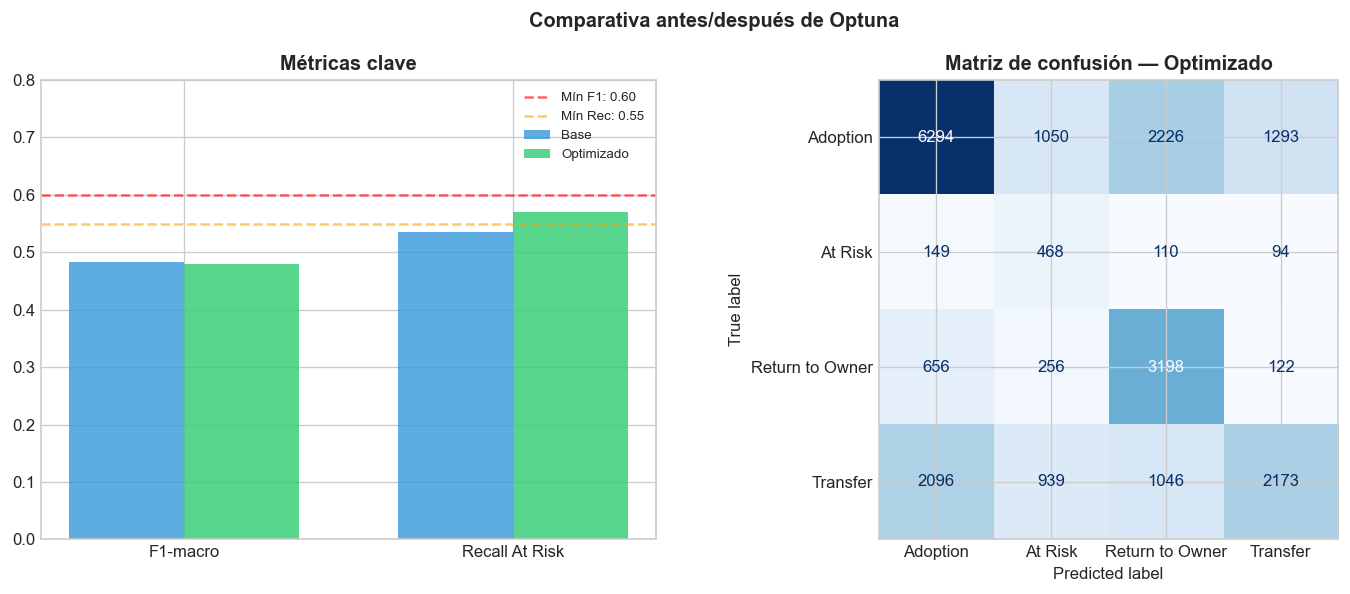

ANÁLISIS DE UMBRALES — At Risk:
    Umbral    Recall AR   Precision AR   F1-macro
  ------------------------------------------------
      0.10       0.8867         0.0608     0.3040
      0.15       0.7990         0.0769     0.3670
      0.20       0.7259         0.0957     0.4120
      0.25       0.6821         0.1091     0.4304
      0.30       0.6078         0.1449     0.4631
      0.35       0.5822         0.1664     0.4756
      0.40       0.5713         0.1714     0.4795 ← MÍNIMO
      0.45       0.5700         0.1724     0.4803 ← MÍNIMO
      0.50       0.5700         0.1725     0.4803 ← MÍNIMO


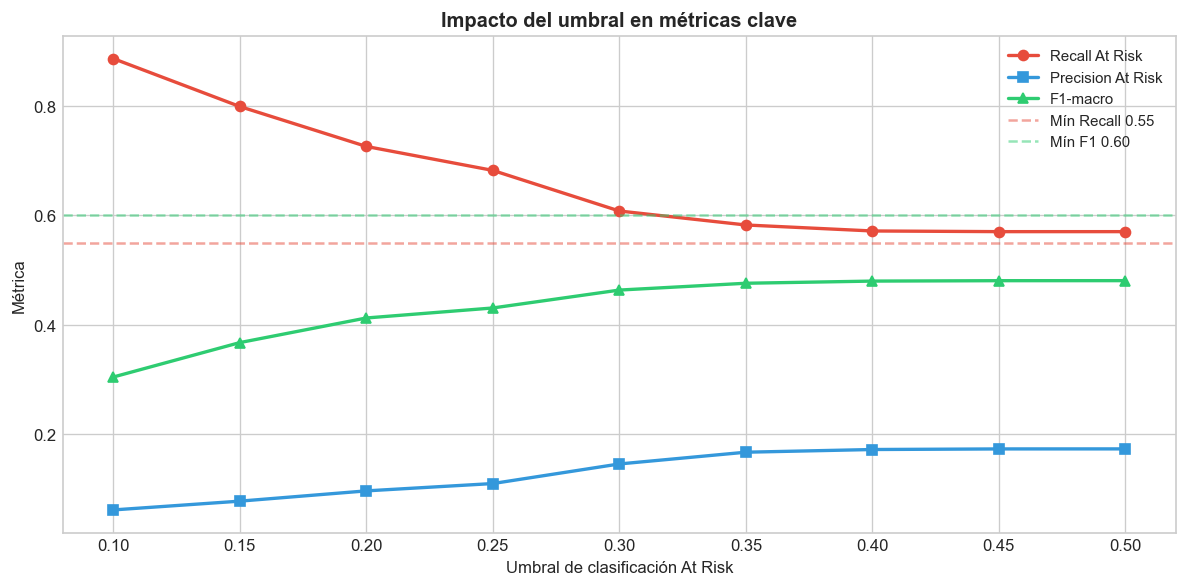


Umbral recomendado: 0.30
StratifiedKFold k=5 sobre train+val...
  Fold 1: F1=0.4759  Recall_AR=0.5860
  Fold 2: F1=0.4805  Recall_AR=0.5738
  Fold 3: F1=0.4803  Recall_AR=0.5351
  Fold 4: F1=0.4764  Recall_AR=0.5808
  Fold 5: F1=0.4865  Recall_AR=0.5982

  F1-macro:     0.4799 ± 0.0038
  Recall AtRisk: 0.5748 ± 0.0214

✅ Modelo estable — baja varianza entre folds


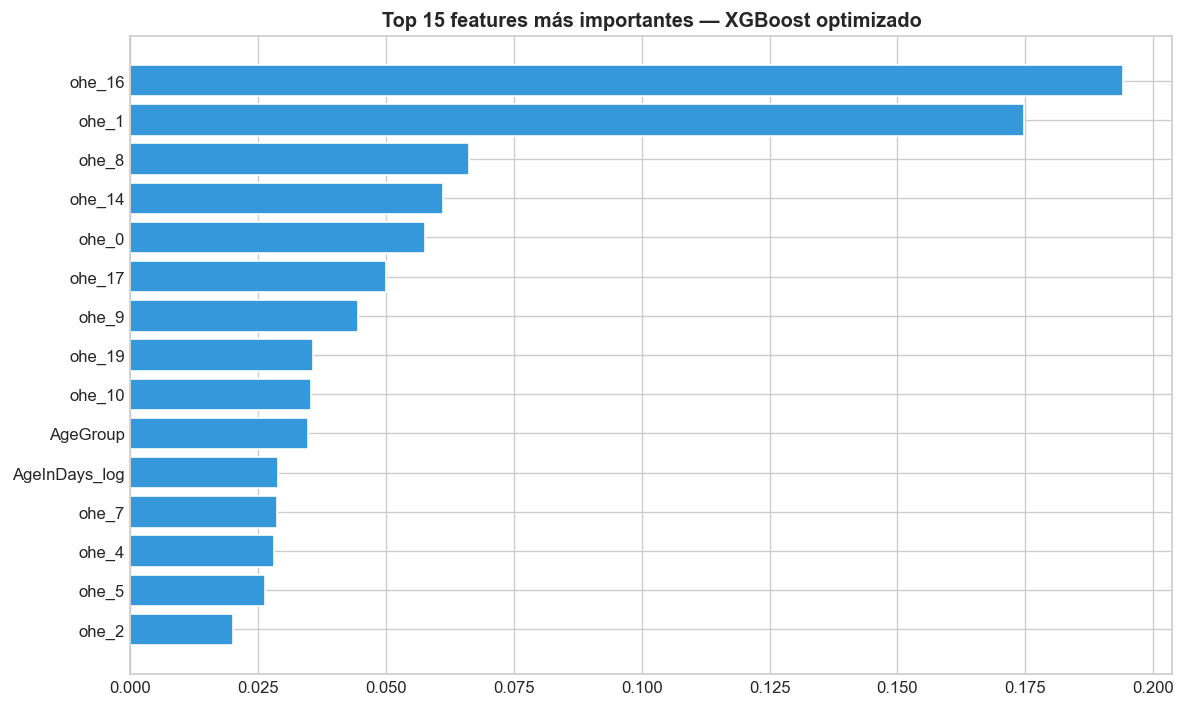

RESUMEN FINAL — MODELO OPTIMIZADO

  Algoritmo:       XGBoost + sample_weight
  Optimización:    Optuna 75 trials

  MÉTRICAS EN VALIDACIÓN:
  ⚠️   F1-macro:      0.4803  (mín: 0.60)
  ✅  Recall AtRisk: 0.5700  (mín: 0.55)
        Accuracy:      0.5473
        Overfitting:   +0.0077

  VALIDACIÓN CRUZADA (k=5):
        F1-macro:      0.4799 ± 0.0038
        Recall AtRisk: 0.5748 ± 0.0214

  Umbral At Risk:  0.30

  Archivos guardados:
    ../models/xgboost_optimizado.pkl
    ../models/umbral_optimo.pkl

  Próximo paso: 05_streamlit_app.py


In [1]:
# %% [markdown]
# # 04 — Optimización con Optuna
# ## Proyecto VI · Clasificación · Austin Animal Center
#
# **Objetivo:** Optimizar los hiperparámetros de XGBoost + sample_weight
# para mejorar F1-macro y Recall At Risk.
#
# **Input:**  `data/processed/splits_procesados.npz`
# **Output:** `models/xgboost_optimizado.pkl`
#
# ---
# ### Índice
# 1. Carga de splits
# 2. Optimización con Optuna
# 3. Resultados — mejor trial
# 4. Entrenar modelo final con mejores parámetros
# 5. Comparativa antes/después de Optuna
# 6. Ajuste de umbral de clasificación
# 7. StratifiedKFold — validación cruzada
# 8. Feature importance
# 9. Serializar modelo final

# %% [markdown]
# ---
# ## 1. Carga de splits

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
import os
warnings.filterwarnings("ignore")

from sklearn.metrics import (f1_score, recall_score, accuracy_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

AT_RISK_IDX = 1
CLASS_NAMES = ["Adoption", "At Risk", "Return to Owner", "Transfer"]
CLASS_ORDER = ["Adoption", "Transfer", "Return to Owner", "At Risk"]

data         = np.load("../data/processed/splits_procesados.npz")
X_train_prep = data["X_train_prep"]
X_val_prep   = data["X_val_prep"]
X_test_prep  = data["X_test_prep"]
y_train      = data["y_train"]
y_val        = data["y_val"]
y_test       = data["y_test"]

os.makedirs("../models", exist_ok=True)
os.makedirs("../reports/figures", exist_ok=True)

# Combinar train + val para StratifiedKFold al final
X_trainval = np.vstack([X_train_prep, X_val_prep])
y_trainval = np.concatenate([y_train, y_val])

print(f"Train:    {X_train_prep.shape}")
print(f"Val:      {X_val_prep.shape}")
print(f"Test:     {X_test_prep.shape}")
print(f"TrainVal: {X_trainval.shape}")

# %% [markdown]
# ---
# ## 2. Optimización con Optuna
#
# Optuna prueba combinaciones de hiperparámetros automáticamente.
# Cada "trial" entrena un XGBoost con parámetros distintos
# y mide el Recall At Risk en validación.
#
# **Métrica a optimizar:** combinación ponderada que prioriza
# Recall At Risk (70%) sobre F1-macro (30%).
# Así forzamos al optimizador a buscar modelos que detecten
# animales en riesgo, no solo modelos con buen F1 general.
#
# **Espacio de búsqueda:**
# | Parámetro | Rango | Efecto |
# |---|---|---|
# | n_estimators | 100-800 | Más árboles → más potencia pero más lento |
# | max_depth | 3-10 | Más profundidad → más capacidad pero más overfitting |
# | learning_rate | 0.01-0.3 | Más bajo → más preciso pero más lento |
# | min_child_weight | 1-10 | Más alto → más conservador |
# | subsample | 0.5-1.0 | % de datos por árbol |
# | colsample_bytree | 0.5-1.0 | % de features por árbol |
# | gamma | 0-5 | Penalización por split |

# %%
def objetivo(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 800),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma":             trial.suggest_float("gamma", 0, 5),
        "random_state":      42,
        "n_jobs":            -1,
        "eval_metric":       "mlogloss",
        "verbosity":         0,
    }

    modelo = XGBClassifier(**params)
    sw     = compute_sample_weight("balanced", y_train)
    modelo.fit(X_train_prep, y_train, sample_weight=sw)

    pred    = modelo.predict(X_val_prep)
    f1      = f1_score(y_val, pred, average="macro")
    rec_ar  = recall_score(y_val, pred, labels=[AT_RISK_IDX], average="macro")

    # Métrica compuesta: 70% Recall At Risk + 30% F1-macro
    return 0.70 * rec_ar + 0.30 * f1


print("Iniciando optimización Optuna — 75 trials...")
print("Métrica: 70% Recall At Risk + 30% F1-macro\n")

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objetivo, n_trials=75, show_progress_bar=True)

print(f"\n✅ Optimización completada")
print(f"   Mejor valor:  {study.best_value:.4f}")
print(f"   Mejor trial:  #{study.best_trial.number}")

# %% [markdown]
# ---
# ## 3. Resultados — mejor trial

# %%
mejores_params = study.best_params
print("MEJORES HIPERPARÁMETROS:")
for k, v in mejores_params.items():
    print(f"  {k:<22} {v}")

# Comparativa con parámetros base
base_params = {
    "n_estimators": 200, "max_depth": 6, "learning_rate": 0.1,
    "min_child_weight": 1, "subsample": 1.0,
    "colsample_bytree": 1.0, "gamma": 0
}
print("\nComparativa base vs optimizado:")
print(f"  {'Parámetro':<22} {'Base':>10} {'Optuna':>10}")
print(f"  {'-'*44}")
for k in base_params:
    v_base   = base_params[k]
    v_optuna = mejores_params.get(k, "—")
    cambio   = " ←" if str(v_base) != str(round(v_optuna, 4) if isinstance(v_optuna, float) else v_optuna) else ""
    print(f"  {k:<22} {str(v_base):>10} {str(round(v_optuna,4) if isinstance(v_optuna,float) else v_optuna):>10}{cambio}")

# Gráfico evolución de trials
fig, ax = plt.subplots(figsize=(12, 4))
valores = [t.value for t in study.trials]
ax.plot(valores, color="#3498db", linewidth=1, alpha=0.6)
ax.plot(np.maximum.accumulate(valores), color="#e74c3c",
        linewidth=2, label="Mejor acumulado")
ax.axhline(max(valores), color="green", linestyle="--",
           alpha=0.5, label=f"Máximo: {max(valores):.4f}")
ax.set_title("Evolución de trials — Optuna", fontweight="bold")
ax.set_xlabel("Trial")
ax.set_ylabel("Métrica (0.7×Recall_AR + 0.3×F1)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/17_optuna_trials.png",
            dpi=150, bbox_inches="tight")
plt.show()

# %% [markdown]
# ---
# ## 4. Entrenar modelo final con mejores parámetros

# %%
xgb_opt = XGBClassifier(
    **mejores_params,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss",
    verbosity=0
)
sw_train = compute_sample_weight("balanced", y_train)
xgb_opt.fit(X_train_prep, y_train, sample_weight=sw_train)

pred_tr  = xgb_opt.predict(X_train_prep)
pred_val = xgb_opt.predict(X_val_prep)

f1_tr    = f1_score(y_train, pred_tr,  average="macro")
f1_val   = f1_score(y_val,   pred_val, average="macro")
rec_ar   = recall_score(y_val, pred_val, labels=[AT_RISK_IDX], average="macro")
acc_val  = accuracy_score(y_val, pred_val)
overfit  = f1_tr - f1_val

ok_f1  = "✅" if f1_val >= 0.60 else "⚠️ "
ok_rec = "✅" if rec_ar >= 0.55 else "⚠️ "
ok_ov  = "✅" if overfit <= 0.05 else "⚠️ "

print("MODELO OPTIMIZADO — resultados en validación:")
print(f"  {ok_f1}  F1-macro:     {f1_val:.4f}  (mín: 0.60)")
print(f"  {ok_rec}  Recall AtRisk: {rec_ar:.4f}  (mín: 0.55)")
print(f"        Accuracy:     {acc_val:.4f}")
print(f"  {ok_ov}  Overfitting:  {overfit:+.4f}  (máx: 0.05)")
print(f"\nReporte completo:")
print(classification_report(y_val, pred_val,
                             target_names=CLASS_NAMES, zero_division=0))

# %% [markdown]
# ---
# ## 5. Comparativa antes/después de Optuna

# %%
# Resultados base (XGBoost + sample_weight sin optimizar)
xgb_base = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, n_jobs=-1, eval_metric="mlogloss", verbosity=0
)
sw_base = compute_sample_weight("balanced", y_train)
xgb_base.fit(X_train_prep, y_train, sample_weight=sw_base)
pred_base = xgb_base.predict(X_val_prep)

f1_base  = f1_score(y_val, pred_base, average="macro")
rec_base = recall_score(y_val, pred_base, labels=[AT_RISK_IDX], average="macro")

print("COMPARATIVA ANTES / DESPUÉS DE OPTUNA:")
print(f"  {'Métrica':<20} {'Base':>10} {'Optimizado':>12} {'Mejora':>10}")
print(f"  {'-'*54}")
print(f"  {'F1-macro':<20} {f1_base:>10.4f} {f1_val:>12.4f} {f1_val-f1_base:>+10.4f}")
print(f"  {'Recall At Risk':<20} {rec_base:>10.4f} {rec_ar:>12.4f} {rec_ar-rec_base:>+10.4f}")
print(f"  {'Accuracy':<20} {accuracy_score(y_val,pred_base):>10.4f} {acc_val:>12.4f} {acc_val-accuracy_score(y_val,pred_base):>+10.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Comparativa antes/después de Optuna", fontweight="bold")

metricas = ["F1-macro", "Recall At Risk"]
antes    = [f1_base, rec_base]
despues  = [f1_val,  rec_ar]
x        = np.arange(len(metricas))
w        = 0.35

axes[0].bar(x - w/2, antes,   w, label="Base",      color="#3498db", alpha=0.8)
axes[0].bar(x + w/2, despues, w, label="Optimizado", color="#2ecc71", alpha=0.8)
axes[0].axhline(0.60, color="red", linestyle="--", alpha=0.6, label="Mín F1: 0.60")
axes[0].axhline(0.55, color="orange", linestyle="--", alpha=0.6, label="Mín Rec: 0.55")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas)
axes[0].set_ylim(0, 0.8)
axes[0].legend(fontsize=8)
axes[0].set_title("Métricas clave", fontweight="bold")

# Matriz de confusión optimizado
cm = confusion_matrix(y_val, pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Matriz de confusión — Optimizado", fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/18_antes_despues_optuna.png",
            dpi=150, bbox_inches="tight")
plt.show()

# %% [markdown]
# ---
# ## 6. Ajuste de umbral de clasificación
#
# En lugar de usar 0.5 como umbral para clasificar At Risk,
# probamos umbrales más bajos para capturar más verdaderos positivos.
# Bajando el umbral aumenta el Recall pero baja la Precision.
# Buscamos el umbral que maximiza el Recall At Risk
# manteniendo una Precision At Risk razonable (> 0.30).

# %%
y_proba   = xgb_opt.predict_proba(X_val_prep)
prob_atrisk = y_proba[:, AT_RISK_IDX]

umbrales  = np.arange(0.10, 0.55, 0.05)
resultados_umb = []

for umb in umbrales:
    # Reclasificar como At Risk si probabilidad > umbral
    y_pred_umb = pred_val.copy()
    y_pred_umb[prob_atrisk >= umb] = AT_RISK_IDX

    rec = recall_score(y_val, y_pred_umb, labels=[AT_RISK_IDX], average="macro")
    from sklearn.metrics import precision_score
    prec = precision_score(y_val, y_pred_umb, labels=[AT_RISK_IDX],
                           average="macro", zero_division=0)
    f1  = f1_score(y_val, y_pred_umb, average="macro")
    resultados_umb.append({"umbral": umb, "recall_ar": rec,
                            "precision_ar": prec, "f1_macro": f1})

df_umb = pd.DataFrame(resultados_umb)

print("ANÁLISIS DE UMBRALES — At Risk:")
print(f"  {'Umbral':>8} {'Recall AR':>12} {'Precision AR':>14} {'F1-macro':>10}")
print(f"  {'-'*48}")
for _, row in df_umb.iterrows():
    ok = " ← MÍNIMO" if abs(row["recall_ar"] - 0.55) < 0.03 else ""
    print(f"  {row['umbral']:>8.2f} {row['recall_ar']:>12.4f} "
          f"{row['precision_ar']:>14.4f} {row['f1_macro']:>10.4f}{ok}")

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_umb["umbral"], df_umb["recall_ar"],
        marker="o", color="#e74c3c", label="Recall At Risk", linewidth=2)
ax.plot(df_umb["umbral"], df_umb["precision_ar"],
        marker="s", color="#3498db", label="Precision At Risk", linewidth=2)
ax.plot(df_umb["umbral"], df_umb["f1_macro"],
        marker="^", color="#2ecc71", label="F1-macro", linewidth=2)
ax.axhline(0.55, color="#e74c3c", linestyle="--", alpha=0.5, label="Mín Recall 0.55")
ax.axhline(0.60, color="#2ecc71", linestyle="--", alpha=0.5, label="Mín F1 0.60")
ax.set_xlabel("Umbral de clasificación At Risk")
ax.set_ylabel("Métrica")
ax.set_title("Impacto del umbral en métricas clave", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../reports/figures/19_analisis_umbral.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Umbral óptimo — mayor Recall AR con F1 > 0.45
mejor_umb = df_umb[df_umb["f1_macro"] >= 0.45].sort_values(
    "recall_ar", ascending=False).iloc[0]["umbral"]
print(f"\nUmbral recomendado: {mejor_umb:.2f}")

# %% [markdown]
# ---
# ## 7. StratifiedKFold — validación cruzada
#
# Entrenamos sobre train+val con StratifiedKFold k=5
# para confirmar que los resultados no son casualidad.
# Si los 5 folds dan métricas similares → el modelo es estable.

# %%
print("StratifiedKFold k=5 sobre train+val...")
skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_folds, rec_folds = [], []

for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_trainval, y_trainval)):
    X_tr_f, X_vl_f = X_trainval[tr_idx], X_trainval[vl_idx]
    y_tr_f, y_vl_f = y_trainval[tr_idx], y_trainval[vl_idx]

    modelo_fold = XGBClassifier(
        **mejores_params,
        random_state=42, n_jobs=-1,
        eval_metric="mlogloss", verbosity=0
    )
    sw_fold = compute_sample_weight("balanced", y_tr_f)
    modelo_fold.fit(X_tr_f, y_tr_f, sample_weight=sw_fold)

    pred_fold = modelo_fold.predict(X_vl_f)
    f1_f  = f1_score(y_vl_f, pred_fold, average="macro")
    rec_f = recall_score(y_vl_f, pred_fold, labels=[AT_RISK_IDX], average="macro")
    f1_folds.append(f1_f)
    rec_folds.append(rec_f)
    print(f"  Fold {fold+1}: F1={f1_f:.4f}  Recall_AR={rec_f:.4f}")

print(f"\n  F1-macro:     {np.mean(f1_folds):.4f} ± {np.std(f1_folds):.4f}")
print(f"  Recall AtRisk: {np.mean(rec_folds):.4f} ± {np.std(rec_folds):.4f}")

if np.std(f1_folds) < 0.02:
    print("\n✅ Modelo estable — baja varianza entre folds")
else:
    print("\n⚠️  Alta varianza entre folds — modelo inestable")

# %% [markdown]
# ---
# ## 8. Feature importance

# %%
importances = xgb_opt.feature_importances_

# Nombres de features (mismo orden que el preprocesador)
# Ajusta si tu preprocesador genera nombres distintos
try:
    feat_names = (
        ["AgeInDays_log"] +
        [f"ohe_{i}" for i in range(len(importances) - 2)] +
        ["AgeGroup"]
    )
except:
    feat_names = [f"feat_{i}" for i in range(len(importances))]

df_imp = pd.DataFrame({"feature": feat_names,
                        "importance": importances})
df_imp = df_imp.sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_imp["feature"], df_imp["importance"],
        color="#3498db", edgecolor="white")
ax.set_title("Top 15 features más importantes — XGBoost optimizado",
             fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/figures/20_feature_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()

# %% [markdown]
# ---
# ## 9. Serializar modelo final

# %%
joblib.dump(xgb_opt, "../models/xgboost_optimizado.pkl")
joblib.dump(mejor_umb, "../models/umbral_optimo.pkl")

print("=" * 55)
print("RESUMEN FINAL — MODELO OPTIMIZADO")
print("=" * 55)
print(f"\n  Algoritmo:       XGBoost + sample_weight")
print(f"  Optimización:    Optuna 75 trials")
print(f"\n  MÉTRICAS EN VALIDACIÓN:")
ok_f1  = "✅" if f1_val >= 0.60 else "⚠️ "
ok_rec = "✅" if rec_ar >= 0.55 else "⚠️ "
print(f"  {ok_f1}  F1-macro:      {f1_val:.4f}  (mín: 0.60)")
print(f"  {ok_rec}  Recall AtRisk: {rec_ar:.4f}  (mín: 0.55)")
print(f"        Accuracy:      {acc_val:.4f}")
print(f"        Overfitting:   {overfit:+.4f}")
print(f"\n  VALIDACIÓN CRUZADA (k=5):")
print(f"        F1-macro:      {np.mean(f1_folds):.4f} ± {np.std(f1_folds):.4f}")
print(f"        Recall AtRisk: {np.mean(rec_folds):.4f} ± {np.std(rec_folds):.4f}")
print(f"\n  Umbral At Risk:  {mejor_umb:.2f}")
print(f"\n  Archivos guardados:")
print(f"    ../models/xgboost_optimizado.pkl")
print(f"    ../models/umbral_optimo.pkl")
print(f"\n  Próximo paso: 05_streamlit_app.py")